### Κατανόηση του Αλγόριθμου K-Means

Ο αλγόριθμος K-Means είναι ένας δημοφιλής αλγόριθμος μη επιβλεπόμενης μάθησης που χρησιμοποιείται για την ομαδοποίηση (clustering) δεδομένων. Στόχος του είναι να διαχωρίσει τα δεδομένα σε $K$ ξεχωριστές, μη επικαλυπτόμενες ομάδες (clusters), όπου κάθε σημείο δεδομένων ανήκει στην ομάδα με τον πλησιέστερο μέσο όρο (ή «κεντροειδές»).

**Πώς λειτουργεί;**

1.  **Επιλογή $K$**: Αρχικά, επιλέγουμε τον αριθμό των ομάδων ($K$) στις οποίες θέλουμε να χωρίσουμε τα δεδομένα.
2.  **Αρχικοποίηση Κεντροειδών**: Επιλέγονται τυχαία $K$ σημεία από τα δεδομένα ως αρχικά κεντροειδή (τα «κέντρα» των ομάδων).
3.  **Αντιστοίχιση Δεδομένων**: Κάθε σημείο δεδομένων αντιστοιχίζεται στην ομάδα του κεντροειδούς που βρίσκεται πιο κοντά του (συνήθως με βάση την Ευκλείδεια απόσταση).
4.  **Ενημέρωση Κεντροειδών**: Τα κεντροειδή κάθε ομάδας υπολογίζονται εκ νέου ως ο μέσος όρος όλων των σημείων που ανήκουν σε αυτήν την ομάδα.
5.  **Επανάληψη**: Τα βήματα 3 και 4 επαναλαμβάνονται μέχρι να μην αλλάζει πλέον η αντιστοίχιση των σημείων στις ομάδες ή μέχρι να επιτευχθεί ένα μέγιστο πλήθος επαναλήψεων.

## Εισαγωγή στο Πρόβλημα Ομαδοποίησης Χρηστών

Σε αυτό το notebook, θα εξερευνήσουμε πώς μπορούμε να ομαδοποιήσουμε χρήστες με βάση τις προτιμήσεις τους σε ταινίες. Φανταστείτε μια πλατφόρμα streaming που συλλέγει δεδομένα για το πόσο "δράσης" ή "κωμωδίας" περιέχει μια ταινία που άρεσε σε κάθε χρήστη. Ο στόχος είναι να εντοπίσουμε διακριτές ομάδες χρηστών που μοιράζονται παρόμοια γούστα.

### Γιατί K-Means για την Ομαδοποίηση Χρηστών;

Ο αλγόριθμος K-Means είναι ιδανικός για την εργασία της ομαδοποίησης χρηστών για διάφορους λόγους:

1.  **Απλότητα και Ταχύτητα**: Είναι σχετικά απλός στην εφαρμογή και αποδοτικός υπολογιστικά, καθιστώντας τον κατάλληλο για μεγάλα σύνολα δεδομένων χρηστών.
2.  **Εύκολη Ερμηνεία Ομάδων**: Οι "κεντροειδείς" κάθε ομάδας (cluster centroids) μπορούν εύκολα να ερμηνευθούν ως το "μέσο προφίλ" των χρηστών εντός αυτής της ομάδας. Για παράδειγμα, μια ομάδα μπορεί να αποτελείται από χρήστες που προτιμούν ταινίες με υψηλό δείκτη δράσης και χαμηλό δείκτη κωμωδίας.
3.  **Δημιουργία Προφίλ Χρηστών**: Μας επιτρέπει να δημιουργήσουμε σαφή προφίλ για κάθε ομάδα χρηστών, τα οποία μπορούν να χρησιμοποιηθούν για:
    *   **Συστάσεις Ταινιών**: Προτείνοντας ταινίες που είναι δημοφιλείς σε άλλους χρήστες της ίδιας ομάδας.
    *   **Στοχευμένες Διαφημίσεις**: Προσαρμόζοντας το περιεχόμενο των διαφημίσεων στις προτιμήσεις κάθε ομάδας.
    *   **Βελτίωση Περιεχομένου**: Κατανοώντας τι είδους περιεχόμενο προσελκύει συγκεκριμένα τμήματα χρηστών.

Σε αυτό το παράδειγμα, θα χρησιμοποιήσουμε δύο χαρακτηριστικά (δείκτης δράσης και δείκτης κωμωδίας) για να ομαδοποιήσουμε συνθετικά δεδομένα ταινιών, προσομοιώνοντας τις προτιμήσεις χρηστών και ανακαλύπτοντας τα υποκείμενα μοτίβα τους.

Πρώτα 5 προφίλ χρηστών:


,Action_Preference,Comedy_Preference
0,8.745071,0.584629
1,7.792604,1.579355
2,8.971533,1.657285
3,10.000000,1.197723
4,7.648770,1.838714



Συνολικός αριθμός χρηστών: 370


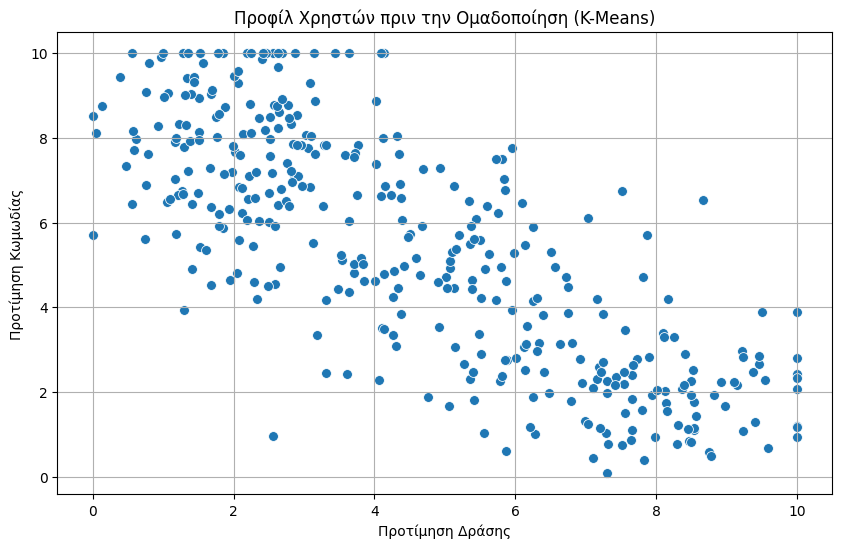

In [ ]:
# Βήμα 1: Εισαγωγή των απαραίτητων βιβλιοθηκών
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Ορισμός τυχαιότητας για αναπαραγωγιμότητα
np.random.seed(42)

# Βήμα 2: Δημιουργία Συνθετικών Δεδομένων Χρηστών
# Θα δημιουργήσουμε 3 "πραγματικές" ομάδες χρηστών για να προσομοιώσουμε ρεαλιστικά σενάρια.

# Ομάδα 1: "Φαν της Δράσης" (High Action Preference, Low Comedy Preference)
# Υψηλή προτίμηση δράσης, χαμηλή προτίμηση κωμωδίας.
n_users_g1 = 100
action_preference_g1 = np.random.normal(loc=8, scale=1.5, size=n_users_g1) # Μέσος όρος 8
comedy_preference_g1 = np.random.normal(loc=2, scale=1, size=n_users_g1) # Μέσος όρος 2

# Ομάδα 2: "Φαν της Κωμωδίας" (Low Action Preference, High Comedy Preference)
# Χαμηλή προτίμηση δράσης, υψηλή προτίμηση κωμωδίας.
n_users_g2 = 150
action_preference_g2 = np.random.normal(loc=2, scale=1, size=n_users_g2) # Μέσος όρος 2
comedy_preference_g2 = np.random.normal(loc=8, scale=1.5, size=n_users_g2) # Μέσος όρος 8

# Ομάδα 3: "Φαν των Ταινιών Δράσης-Κωμωδίας" (Balanced Action-Comedy Preference)
# Μέτριες προτιμήσεις και στα δύο χαρακτηριστικά.
n_users_g3 = 120
action_preference_g3 = np.random.normal(loc=5, scale=1.5, size=n_users_g3) # Μέσος όρος 5
comedy_preference_g3 = np.random.normal(loc=5, scale=1.5, size=n_users_g3) # Μέσος όρος 5

# Συνδυασμός των δεδομένων σε ένα DataFrame
action_preference = np.concatenate([action_preference_g1, action_preference_g2, action_preference_g3])
comedy_preference = np.concatenate([comedy_preference_g1, comedy_preference_g2, comedy_preference_g3])

# Εξασφάλιση ότι οι τιμές είναι εντός του εύρους [0, 10]
action_preference = np.clip(action_preference, 0, 10)
comedy_preference = np.clip(comedy_preference, 0, 10)

data = pd.DataFrame({
    'Action_Preference': action_preference,
    'Comedy_Preference': comedy_preference
})

print("Πρώτα 5 προφίλ χρηστών:")
display(data.head())
print(f"\nΣυνολικός αριθμός χρηστών: {len(data)}")

# Βήμα 3: Οπτικοποίηση των μη ομαδοποιημένων δεδομένων
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Action_Preference', y='Comedy_Preference', data=data, s=50) # Removed palette argument
plt.title('Προφίλ Χρηστών πριν την Ομαδοποίηση (K-Means)')
plt.xlabel('Προτίμηση Δράσης')
plt.ylabel('Προτίμηση Κωμωδίας')
plt.grid(True)
plt.show()

Πρώτα 5 προφίλ χρηστών με τις ομάδες:


,Action_Preference,Comedy_Preference,Cluster
0,8.745071,0.584629,2
1,7.792604,1.579355,2
2,8.971533,1.657285,2
3,10.000000,1.197723,2
4,7.648770,1.838714,2



Συντεταγμένες των κεντροειδών:
[[2.09156164 8.00751673]
 [4.74745885 5.0143525 ]
 [7.74408506 2.08104229]]


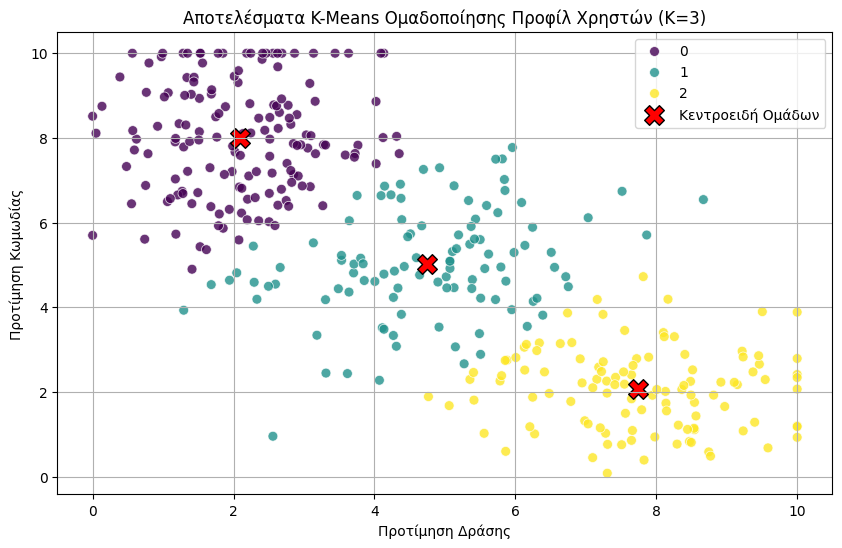


Περίληψη χαρακτηριστικών ανά ομάδα (Μέσοι Όροι):


,Action_Preference,Comedy_Preference
Cluster,,
0,2.091562,8.007517
1,4.747459,5.014352
2,7.744085,2.081042



Από την ανάλυση, μπορούμε να δούμε:

- **Ομάδα 0 (π.χ., 'Φαν της Κωμωδίας')**: Χαμηλή προτίμηση δράσης, υψηλή προτίμηση κωμωδίας.
- **Ομάδα 1 (π.χ., 'Φαν των Ταινιών Δράσης-Κωμωδίας')**: Μέτριες προτιμήσεις δράσης και κωμωδίας.
- **Ομάδα 2 (π.χ., 'Φαν της Δράσης')**: Υψηλή προτίμηση δράσης, χαμηλή προτίμηση κωμωδίας.

Αυτή η τμηματοποίηση μπορεί να χρησιμοποιηθεί για να προτείνει ταινίες σε χρήστες ή να οργανώσει βιβλιοθήκες ταινιών.


In [ ]:
# Βήμα 4: Εφαρμογή του αλγορίθμου K-Means

# Επιλέγουμε τον αριθμό των ομάδων (K).
# Επειδή δημιουργήσαμε 3 ομάδες χρηστών, θα προσπαθήσουμε να βρούμε K=3.
# Στην πραγματικότητα, ο καθορισμός του K μπορεί να γίνει με άλλες μεθόδους (π.χ. Elbow Method, Silhouette Score).
n_clusters = 3

# Δημιουργία του μοντέλου K-Means
# `n_clusters`: Ο αριθμός των ομάδων που θέλουμε να βρούμε.
# `init='k-means++'`: Μια έξυπνη μέθοδος αρχικοποίησης των κεντροειδών που επιταχύνει τη σύγκλιση.
# `random_state`: Για αναπαραγωγιμότητα των αποτελεσμάτων (οι τυχαίες αρχικές επιλογές θα είναι πάντα ίδιες).
# `n_init='auto'`: Κάνουμε πολλαπλές εκτελέσεις με διαφορετικά κεντροειδή και επιλέγουμε την καλύτερη λύση.
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init='auto')

# Εκπαίδευση του μοντέλου στα δεδομένα προτιμήσεων χρηστών μας
# Ο αλγόριθμος θα βρει τις βέλτιστες ομάδες και τα κεντροειδή.
kmeans.fit(data[['Action_Preference', 'Comedy_Preference']])

# Βήμα 5: Λήψη των αποτελεσμάτων

# `labels_`: Αυτός ο πίνακας περιέχει την ομάδα στην οποία ανήκει κάθε προφίλ χρήστη.
# Κάθε τιμή αντιστοιχεί σε έναν αριθμό ομάδας (π.χ., 0, 1, 2).
cluster_labels = kmeans.labels_

# `cluster_centers_`: Αυτός ο πίνακας περιέχει τις συντεταγμένες των κεντροειδών για κάθε ομάδα.
# Κάθε γραμμή αντιστοιχεί σε ένα κεντροειδές, και οι στήλες στα χαρακτηριστικά (Προτίμηση Δράσης, Προτίμηση Κωμωδίας).
centroids = kmeans.cluster_centers_

# Προσθήκη των ετικετών ομάδας στο αρχικό μας DataFrame
data['Cluster'] = cluster_labels

print("Πρώτα 5 προφίλ χρηστών με τις ομάδες:")
display(data.head())
print("\nΣυντεταγμένες των κεντροειδών:")
print(centroids)

# Βήμα 6: Οπτικοποίηση των αποτελεσμάτων της ομαδοποίησης
plt.figure(figsize=(10, 6))

# Δημιουργία scatter plot, χρωματίζοντας τα σημεία ανάλογα με την ομάδα τους
sns.scatterplot(x='Action_Preference', y='Comedy_Preference', hue='Cluster', data=data,
                palette='viridis', s=50, alpha=0.8, legend='full')

# Σχεδίαση των κεντροειδών των ομάδων
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X',
            edgecolor='black', label='Κεντροειδή Ομάδων')

plt.title('Αποτελέσματα K-Means Ομαδοποίησης Προφίλ Χρηστών (K=3)')
plt.xlabel('Προτίμηση Δράσης')
plt.ylabel('Προτίμηση Κωμωδίας')
plt.grid(True)
plt.legend()
plt.show()

# Βήμα 7: Ανάλυση των Ομάδων (Προαιρετικό αλλά χρήσιμο για την κατανόηση)

# Υπολογισμός του μέσου όρου για κάθε χαρακτηριστικό ανά ομάδα
cluster_summary = data.groupby('Cluster')[['Action_Preference', 'Comedy_Preference']].mean()

print("\nΠερίληψη χαρακτηριστικών ανά ομάδα (Μέσοι Όροι):")
display(cluster_summary)

print("\nΑπό την ανάλυση, μπορούμε να δούμε:")
print("\n- **Ομάδα 0 (π.χ., 'Φαν της Κωμωδίας')**: Χαμηλή προτίμηση δράσης, υψηλή προτίμηση κωμωδίας.")
print("- **Ομάδα 1 (π.χ., 'Φαν των Ταινιών Δράσης-Κωμωδίας')**: Μέτριες προτιμήσεις δράσης και κωμωδίας.")
print("- **Ομάδα 2 (π.χ., 'Φαν της Δράσης')**: Υψηλή προτίμηση δράσης, χαμηλή προτίμηση κωμωδίας.")
print("\nΑυτή η τμηματοποίηση μπορεί να χρησιμοποιηθεί για να προτείνει ταινίες σε χρήστες ή να οργανώσει βιβλιοθήκες ταινιών.")

### Εύρεση του βέλτιστου αριθμού K: Η Elbow Method

Μέχρι τώρα, επιλέξαμε τον αριθμό των ομάδων ($K$) αυθαίρετα (K=3), επειδή γνωρίζαμε εκ των προτέρων πόσες ομάδες είχαμε δημιουργήσει συνθετικά. Στον πραγματικό κόσμο, όμως, δεν γνωρίζουμε τον βέλτιστο αριθμό $K$.

Η **Elbow Method** είναι μια δημοφιλ ευρετική τεχνική που χρησιμοποιείται για την εύρεση του βέλτιστου αριθμού clusters ($K$) σε έναν αλγόριθμο K-Means. Η ιδέα είναι να εκτελέσουμε τον αλγόριθμο K-Means για μια σειρά τιμών του $K$ και να υπολογίσουμε το **"within-cluster sum of squares" (WCSS)** για κάθε τιμή.

*   **WCSS (Inertia)**: Μετρά το άθροισμα των τετραγώνων των αποστάσεων μεταξύ κάθε σημείου δεδομένων και του κεντροειδούς της ομάδας στην οποία ανήκει. Μικρότερο WCSS σημαίνει ότι τα σημεία δεδομένων είναι πιο κοντά στα κεντροειδή τους, δηλαδή οι ομάδες είναι πιο συμπαγείς.

**Πώς λειτουργεί η Elbow Method;**

1.  **Εκτέλεση K-Means για διαφορετικά K**: Εκτελούμε τον αλγόριθμο K-Means για διαφορετικές τιμές του $K$ (π.χ., από 1 έως 10).
2.  **Υπολογισμός WCSS**: Για κάθε $K$, καταγράφουμε την τιμή του WCSS.
3.  **Οπτικοποίηση**: Σχεδιάζουμε ένα γράφημα με τις τιμές του $K$ στον άξονα x και τις αντίστοιχες τιμές του WCSS στον άξονα y.
4.  **Εύρεση του "αγκώνα"**: Αναζητούμε το σημείο στο γράφημα όπου η μείωση του WCSS αρχίζει να επιβραδύνεται σημαντικά, σχηματίζοντας έναν "αγκώνα". Αυτό το σημείο θεωρείται συχνά ο βέλτιστος αριθμός $K$, καθώς η προσθήκη περισσότερων clusters πέρα από αυτό το σημείο προσφέρει μειούμενα οφέλη στην εξήγηση της διακύμανσης των δεδομένων.

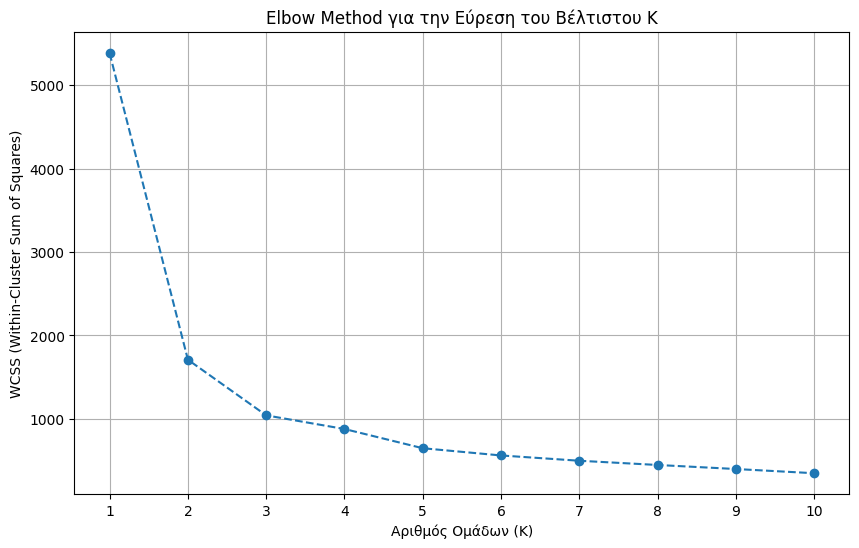


Από το γράφημα της Elbow Method, αναζητούμε το σημείο όπου η καμπύλη αρχίζει να ισοπεδώνεται (ο 'αγκώνας').
Σε αυτήν την περίπτωση, ο 'αγκώνας' φαίνεται να βρίσκεται στο K=3, το οποίο επιβεβαιώνει την αρχική μας υπόθεση.


In [ ]:
# Βήμα 8: Εφαρμογή της Elbow Method

wcss = []
# Δοκιμάζουμε τιμές του K από 1 έως 10
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans_elbow.fit(data[['Action_Preference', 'Comedy_Preference']])
    # Η ιδιότητα 'inertia_' αποθηκεύει την τιμή του WCSS
    wcss.append(kmeans_elbow.inertia_)

# Οπτικοποίηση της Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method για την Εύρεση του Βέλτιστου K')
plt.xlabel('Αριθμός Ομάδων (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("\nΑπό το γράφημα της Elbow Method, αναζητούμε το σημείο όπου η καμπύλη αρχίζει να ισοπεδώνεται (ο 'αγκώνας').")
print("Σε αυτήν την περίπτωση, ο 'αγκώνας' φαίνεται να βρίσκεται στο K=3, το οποίο επιβεβαιώνει την αρχική μας υπόθεση.")